In [1]:
# House price prediction project
# importing libraries and dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_excel(r"C:\Users\Thvelonis\Downloads\HousePricePrediction.xlsx")
print(dataset.head())


   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [2]:
# dataset dimensions
dataset.shape


(2919, 13)

In [3]:
# data preprocessing
int_cols = dataset.select_dtypes(include = ["int64"]).columns
print("Integer variables:", len(int_cols))

float_cols = dataset.select_dtypes(include = ["float64"]).columns
print("Floating point variables:", len(float_cols))

categorical_cols = dataset.select_dtypes(include = ["object"]).columns
print("Categorical variables:", len(categorical_cols))


Integer variables: 6
Floating point variables: 3
Categorical variables: 4


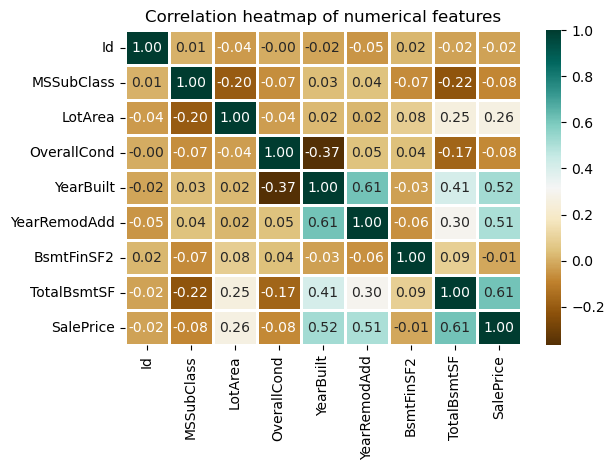

In [4]:
# exploratory data analysis (EDA)
# numerical features correlations visualization
numerical_dataset = dataset.select_dtypes(include = ["int64", "float64"])

plt.figure()
sns.heatmap(numerical_dataset.corr(), cmap = "BrBG", fmt = ".2f", linewidths = 2, annot = True)
plt.title("Correlation heatmap of numerical features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")


<Axes: title={'center': 'Number of unique values of categorical features'}, xlabel='None'>

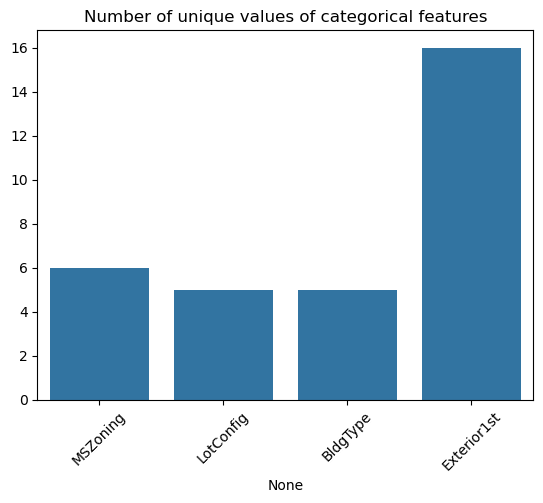

In [5]:
# categorical features examination
unique_values = []  # empty list
for col in categorical_cols:
    unique_values.append(dataset[col].unique().size)

plt.figure()
plt.title("Number of unique values of categorical features")
plt.xticks(rotation = 45)

sns.barplot(x = categorical_cols, y = unique_values)


In [6]:
# data cleaning
# dropping 'Id' column, as it will not participating in any prediction
dataset.drop(["Id"], axis = 1, inplace = True)
print(dataset.head())


   MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  YearBuilt  \
0          60       RL     8450    Inside     1Fam            5       2003   
1          20       RL     9600       FR2     1Fam            8       1976   
2          60       RL    11250    Inside     1Fam            5       2001   
3          70       RL     9550    Corner     1Fam            5       1915   
4          60       RL    14260       FR2     1Fam            5       2000   

   YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0          2003     VinylSd         0.0        856.0   208500.0  
1          1976     MetalSd         0.0       1262.0   181500.0  
2          2002     VinylSd         0.0        920.0   223500.0  
3          1970     Wd Sdng         0.0        756.0   140000.0  
4          2000     VinylSd         0.0       1145.0   250000.0  


In [7]:
# replacing 'SalePrice' empty values with column's mean value
dataset["SalePrice"] = dataset["SalePrice"].fillna(dataset["SalePrice"].mean())


In [8]:
# dropping records with null values
new_dataset = dataset.dropna()


In [9]:
# checking to see any features with null values
new_dataset.isnull().sum()


MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [10]:
# one hot encoding for mapping the categorical values to integer values
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == "object")
object_cols = list(s[s].index)  # list of categorical variables

# creating OneHotEncoder
OH_encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")

OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()

final_df = new_dataset.drop(object_cols, axis = 1)
final_df = pd.concat([final_df, OH_cols], axis = 1)


In [11]:
# splitting dataset into training and testing sets
from sklearn.model_selection import train_test_split

Y = final_df["SalePrice"]
X = final_df.drop(["SalePrice"], axis = 1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size = 0.8, test_size = 0.2, random_state = 0)


In [12]:
# creating, training, and evaluating different models
# SVM - Support Vector Machine algorithm
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

SVR_model = svm.SVR()
SVR_model.fit(X_train, Y_train)
SVR_model_pred = SVR_model.predict(X_test)

print("SVM model error:", mean_absolute_percentage_error(Y_test, SVR_model_pred))


SVM model error: 0.1870512931870423


In [13]:
# Random Forest algorithm
from sklearn.ensemble import RandomForestRegressor

RF_model = RandomForestRegressor(n_estimators = 10)
RF_model.fit(X_train, Y_train)
RF_model_pred = RF_model.predict(X_test)

print("RF model error:", mean_absolute_percentage_error(Y_test, RF_model_pred))


RF model error: 0.1949838967419942
